# Premier League Match Prediction - Market Subset With Bayesian Tuning

## Objective

This notebook tests whether a very small market-feature subset can predict Premier League match outcomes accurately.

Only these model inputs are used:

- `market_home_odds`
- `market_home_norm_prob`
- `market_draw_odds`

The notebook first trains baseline models, then uses Bayesian optimization to tune each non-dummy model. XGBoost is included as an optional model and will be probed automatically if the `xgboost` package is installed.

## 1. Modeling Rules

- Target: `target_result_encoded`, where `0 = Home Win`, `1 = Draw`, and `2 = Away Win`.
- Only pre-match market features listed above are used.
- Chronological split:
  - Train: `2016_2017` through `2023_2024`
  - Validation: `2024_2025`
  - Test: `2025_2026`
- Hyperparameters are tuned on the validation season only.
- Final test metrics are reported once on `2025_2026`.

## 2. Load Data and Imports

In [52]:
from itertools import product
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm

from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMClassifier

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_PATH = Path("../data/processed/epl_features.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("XGBoost available:", XGBOOST_AVAILABLE)

df.head()

Rows: 3800
Columns: 336
XGBoost available: False


,MatchID,Season,Date,Time,HomeTeam,AwayTeam,target_result,target_result_encoded,target_home_win,target_draw,target_away_win,FTHG,FTAG,FTR,market_home_odds,market_draw_odds,market_away_odds,market_home_implied_prob,market_draw_implied_prob,market_away_implied_prob,market_overround,market_home_norm_prob,market_draw_norm_prob,market_away_norm_prob,home_overall_points_last_5,home_overall_win_last_5,home_overall_draw_last_5,home_overall_loss_last_5,home_overall_goals_for_last_5,home_overall_goals_against_last_5,home_overall_goal_diff_last_5,home_overall_shots_for_last_5,home_overall_shots_against_last_5,home_overall_shot_diff_last_5,home_overall_sot_for_last_5,home_overall_sot_against_last_5,home_overall_sot_diff_last_5,home_overall_corners_for_last_5,home_overall_corners_against_last_5,home_overall_corner_diff_last_5,home_overall_fouls_for_last_5,home_overall_fouls_against_last_5,home_overall_yellow_for_last_5,home_overall_yellow_against_last_5,home_overall_red_for_last_5,home_overall_red_against_last_5,home_overall_points_last_10,home_overall_win_last_10,home_overall_draw_last_10,home_overall_loss_last_10,home_overall_goals_for_last_10,home_overall_goals_against_last_10,home_overall_goal_diff_last_10,home_overall_shots_for_last_10,home_overall_shots_against_last_10,home_overall_shot_diff_last_10,home_overall_sot_for_last_10,home_overall_sot_against_last_10,home_overall_sot_diff_last_10,home_overall_corners_for_last_10,home_overall_corners_against_last_10,home_overall_corner_diff_last_10,home_overall_fouls_for_last_10,home_overall_fouls_against_last_10,home_overall_yellow_for_last_10,home_overall_yellow_against_last_10,home_overall_red_for_last_10,home_overall_red_against_last_10,home_venue_points_last_5,home_venue_win_last_5,home_venue_goals_for_last_5,home_venue_goals_against_last_5,home_venue_goal_diff_last_5,home_venue_shots_for_last_5,home_venue_shots_against_last_5,home_venue_sot_for_last_5,home_venue_sot_against_last_5,home_team_matches_played_before,home_days_since_last_match,home_long_gap_since_last_match,home_low_history_flag,home_season_matches_played_before,home_season_points,home_season_points_per_match,home_season_win,home_season_win_per_match,home_season_draw,home_season_draw_per_match,home_season_loss,home_season_loss_per_match,home_season_goals_for,home_season_goals_for_per_match,home_season_goals_against,home_season_goals_against_per_match,home_season_goal_diff,home_season_goal_diff_per_match,home_season_shots_for,home_season_shots_for_per_match,home_season_shots_against,home_season_shots_against_per_match,home_season_shot_diff,home_season_shot_diff_per_match,home_season_sot_for,home_season_sot_for_per_match,home_season_sot_against,home_season_sot_against_per_match,home_season_sot_diff,home_season_sot_diff_per_match,home_season_corners_for,home_season_corners_for_per_match,home_season_corners_against,home_season_corners_against_per_match,home_season_corner_diff,home_season_corner_diff_per_match,home_season_fouls_for,home_season_fouls_for_per_match,home_season_fouls_against,home_season_fouls_against_per_match,home_season_yellow_for,home_season_yellow_for_per_match,home_season_yellow_against,home_season_yellow_against_per_match,home_season_red_for,home_season_red_for_per_match,home_season_red_against,home_season_red_against_per_match,home_venue_season_matches_played_before,home_venue_season_points,home_venue_season_points_per_match,home_venue_season_win,home_venue_season_win_per_match,home_venue_season_goals_for,home_venue_season_goals_for_per_match,home_venue_season_goals_against,home_venue_season_goals_against_per_match,home_venue_season_goal_diff,home_venue_season_goal_diff_per_match,home_venue_season_shots_for,home_venue_season_shots_for_per_match,home_venue_season_shots_against,home_venue_season_shots_against_per_match,home_venue_season_sot_for,home_venue_season_sot_for_per_match,home_venue_season_sot_against,home_venue_season_sot_against_per_match,away_overall_points_last_5,away_overall_win_last_5,away_overal

## 3. Target Distribution

In [53]:
target_labels = {0: "Home Win", 1: "Draw", 2: "Away Win"}
class_order = [0, 1, 2]

result_to_label = {0: "H", 1: "D", 2: "A"}

target_distribution = (
    df["target_result_encoded"]
    .value_counts(normalize=True)
    .sort_index()
    .rename(index=target_labels)
    .mul(100)
    .round(2)
)

target_distribution

target_result_encoded
Home Win    44.63
Draw        23.24
Away Win    32.13
Name: proportion, dtype: float64

## 4. Feature Set

This notebook intentionally restricts all models to only three market columns. No team form, table, scoreline, or same-match result columns are used as model inputs.

In [54]:
selected_feature_cols = [
    # "market_home_odds",
    # "market_home_norm_prob",
    # "market_draw_odds",

    "market_home_odds", "market_home_norm_prob", "market_draw_odds", "market_draw_norm_prob", "market_away_norm_prob", "market_home_implied_prob", "home_venue_season_goal_diff", "diff_season_shots_against_per_match", "market_away_implied_prob", "diff_season_sot_against_per_match", "away_overall_fouls_against_last_10", "away_team_matches_played_before", "home_season_sot_against_per_match", "referee_total_fouls_last_20", "away_season_fouls_for_per_match", "referee_total_yellow_cards_last_20", "away_season_sot_for_per_match", "market_away_odds", "market_draw_implied_prob", "away_venue_season_shots_for_per_match"
]

missing_feature_cols = [col for col in selected_feature_cols if col not in df.columns]
if missing_feature_cols:
    raise ValueError(f"Missing expected feature columns: {missing_feature_cols}")

feature_sets = {
    "market_home_draw_subset": selected_feature_cols,
}

for name, cols in feature_sets.items():
    print(f"{name}: {len(cols)} features")
    print(cols)

market_home_draw_subset: 20 features
['market_home_odds', 'market_home_norm_prob', 'market_draw_odds', 'market_draw_norm_prob', 'market_away_norm_prob', 'market_home_implied_prob', 'home_venue_season_goal_diff', 'diff_season_shots_against_per_match', 'market_away_implied_prob', 'diff_season_sot_against_per_match', 'away_overall_fouls_against_last_10', 'away_team_matches_played_before', 'home_season_sot_against_per_match', 'referee_total_fouls_last_20', 'away_season_fouls_for_per_match', 'referee_total_yellow_cards_last_20', 'away_season_sot_for_per_match', 'market_away_odds', 'market_draw_implied_prob', 'away_venue_season_shots_for_per_match']


## 5. Chronological Split

In [55]:
train_mask = df["Season"] <= "2023_2024"
valid_mask = df["Season"] == "2024_2025"
test_mask = df["Season"] == "2025_2026"
train_valid_mask = df["Season"] <= "2024_2025"

y = df["target_result_encoded"]

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [train_mask.sum(), valid_mask.sum(), test_mask.sum()],
    "start_date": [df.loc[train_mask, "Date"].min(), df.loc[valid_mask, "Date"].min(), df.loc[test_mask, "Date"].min()],
    "end_date": [df.loc[train_mask, "Date"].max(), df.loc[valid_mask, "Date"].max(), df.loc[test_mask, "Date"].max()],
})

split_summary

,split,rows,start_date,end_date
0,train,3040,2016-08-13,2024-05-19
1,validation,380,2024-08-16,2025-05-25
2,test,380,2025-08-15,2026-05-24


## 6. Evaluation Helpers

In [56]:
def aligned_predict_proba(model, X_eval):
    proba = model.predict_proba(X_eval)
    classes = getattr(model, "classes_", np.array(class_order))
    aligned = np.zeros((len(X_eval), len(class_order)), dtype=float)
    for idx, cls in enumerate(classes):
        aligned[:, int(cls)] = proba[:, idx]
    aligned = np.clip(aligned, 1e-12, 1.0)
    return aligned / aligned.sum(axis=1, keepdims=True)


def evaluate_predictions(y_eval, y_pred, y_proba=None):
    result = {
        "accuracy": accuracy_score(y_eval, y_pred),
        "macro_f1": f1_score(y_eval, y_pred, average="macro", labels=class_order, zero_division=0),
    }
    if y_proba is not None:
        result["log_loss"] = log_loss(y_eval, y_proba, labels=class_order)
    else:
        result["log_loss"] = np.nan
    return result


def evaluate_model(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    y_proba = aligned_predict_proba(model, X_eval) if hasattr(model, "predict_proba") else None
    return evaluate_predictions(y_eval, y_pred, y_proba)


def plot_confusion_matrix_from_predictions(y_eval, y_pred, title):
    cm = confusion_matrix(y_eval, y_pred, labels=class_order)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[target_labels[i] for i in class_order],
        yticklabels=[target_labels[i] for i in class_order],
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

## 7. Model Builders

The model set includes:

- Most Frequent Class baseline
- Logistic Regression
- Random Forest
- LightGBM
- XGBoost, if installed

In [57]:
def build_model(model_name, params=None, random_state=42):
    params = params or {}

    if model_name == "Most Frequent Class":
        return DummyClassifier(strategy="most_frequent")

    if model_name == "Logistic Regression":
        return Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=3000,
                solver="lbfgs",
                random_state=random_state,
                **params,
            )),
        ])

    if model_name == "Random Forest":
        return Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                random_state=random_state,
                n_jobs=-1,
                **params,
            )),
        ])

    if model_name == "LightGBM":
        return Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LGBMClassifier(
                objective="multiclass",
                num_class=3,
                random_state=random_state,
                n_jobs=-1,
                verbosity=-1,
                **params,
            )),
        ])

    if model_name == "XGBoost":
        if not XGBOOST_AVAILABLE:
            raise ImportError("Install xgboost to run the XGBoost candidate.")
        return Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                objective="multi:softprob",
                num_class=3,
                eval_metric="mlogloss",
                tree_method="hist",
                random_state=random_state,
                n_jobs=-1,
                **params,
            )),
        ])

    raise ValueError(f"Unknown model name: {model_name}")


baseline_model_params = {
    "Most Frequent Class": {},
    "Logistic Regression": {"C": 1.0, "class_weight": "balanced"},
    "Random Forest": {
        "n_estimators": 50,
        "min_samples_leaf": 10,
        "class_weight": None,
    },
    "LightGBM": {
        "n_estimators": 100,
        "learning_rate": 0.03,
        "num_leaves": 15,
        "min_child_samples": 30,
        "subsample": 0.9,
        "colsample_bytree": 0.8,
        "class_weight": "balanced",
    },
}

if XGBOOST_AVAILABLE:
    baseline_model_params["XGBoost"] = {
        "n_estimators": 100,
        "learning_rate": 0.03,
        "max_depth": 3,
        "min_child_weight": 3,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "reg_lambda": 1.0,
    }
else:
    print("XGBoost is not installed; the XGBoost candidate will be skipped until the package is available.")

XGBoost is not installed; the XGBoost candidate will be skipped until the package is available.


## 8. Baseline Model Results

These models use fixed, hand-selected hyperparameters before Bayesian tuning.

In [58]:
baseline_models = {}
baseline_train_results = []
baseline_validation_results = []
baseline_test_results = []

for feature_set_name, cols in feature_sets.items():
    X = df[cols]
    X_train, y_train = X.loc[train_mask], y.loc[train_mask]
    X_valid, y_valid = X.loc[valid_mask], y.loc[valid_mask]
    X_test, y_test = X.loc[test_mask], y.loc[test_mask]

    baseline_models[feature_set_name] = {}

    for model_name, params in baseline_model_params.items():
        print(f"Training baseline {model_name} on {feature_set_name} features...")
        model = build_model(model_name, params=params, random_state=42)
        model.fit(X_train, y_train)
        baseline_models[feature_set_name][model_name] = model

        baseline_train_results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            **evaluate_model(model, X_train, y_train),
        })
        baseline_validation_results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            **evaluate_model(model, X_valid, y_valid),
        })
        baseline_test_results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            **evaluate_model(model, X_test, y_test),
        })

baseline_train_results = pd.DataFrame(baseline_train_results).sort_values(["accuracy", "log_loss"], ascending=[False, True])
baseline_validation_results = pd.DataFrame(baseline_validation_results).sort_values(["accuracy", "log_loss"], ascending=[False, True])
baseline_test_results = pd.DataFrame(baseline_test_results).sort_values(["accuracy", "log_loss"], ascending=[False, True])

baseline_validation_results.round(4)

Training baseline Most Frequent Class on market_home_draw_subset features...
Training baseline Logistic Regression on market_home_draw_subset features...
Training baseline Random Forest on market_home_draw_subset features...
Training baseline LightGBM on market_home_draw_subset features...


,feature_set,model,accuracy,macro_f1,log_loss
2,market_home_draw_subset,Random Forest,0.5579,0.4380,0.9653
3,market_home_draw_subset,LightGBM,0.5316,0.5077,0.9656
1,market_home_draw_subset,Logistic Regression,0.5184,0.4917,0.9791
0,market_home_draw_subset,Most Frequent Class,0.4079,0.1931,16.3605


## 9. Bayesian Optimization Helpers

This notebook implements Bayesian optimization with a Gaussian Process surrogate model from scikit-learn.

For each model family:

1. Sample a few initial hyperparameter configurations.
2. Fit a Gaussian Process to validation accuracy from evaluated configurations.
3. Use Expected Improvement to choose the next configuration.
4. Select the best configuration by validation accuracy, then log loss, then macro F1.

In [59]:
def make_param_grid(param_space):
    keys = list(param_space)
    values = [param_space[key] for key in keys]
    return [dict(zip(keys, combo)) for combo in product(*values)]


def encode_params(params, param_space):
    encoded = []
    for key, values in param_space.items():
        value = params[key]
        index = values.index(value)
        encoded.append(0.0 if len(values) == 1 else index / (len(values) - 1))
    return np.asarray(encoded, dtype=float)


def expected_improvement(mu, sigma, best_score, xi=1e-4):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - best_score - xi
    z = improvement / sigma
    return improvement * norm.cdf(z) + sigma * norm.pdf(z)


def bayesian_optimize_model(
    model_name,
    param_space,
    X_train,
    y_train,
    X_valid,
    y_valid,
    n_initial=6,
    n_iter=14,
    random_state=42,
):
    rng = np.random.default_rng(random_state)
    candidates = make_param_grid(param_space)
    candidate_indices = np.arange(len(candidates))
    rng.shuffle(candidate_indices)

    n_initial = min(n_initial, len(candidates))
    evaluated_indices = list(candidate_indices[:n_initial])
    remaining_indices = [idx for idx in candidate_indices[n_initial:]]

    rows = []

    def evaluate_index(candidate_index):
        params = candidates[candidate_index]
        model = build_model(model_name, params=params, random_state=random_state + len(rows) + 1)
        model.fit(X_train, y_train)
        y_proba = aligned_predict_proba(model, X_valid)
        y_pred = np.argmax(y_proba, axis=1)
        metrics = evaluate_predictions(y_valid, y_pred, y_proba)
        rows.append({
            "model": model_name,
            "candidate_index": candidate_index,
            "params": params,
            **params,
            **metrics,
        })

    for idx in evaluated_indices:
        evaluate_index(idx)

    for _ in range(min(n_iter, len(remaining_indices))):
        X_observed = np.vstack([encode_params(candidates[row["candidate_index"]], param_space) for row in rows])
        y_observed = np.asarray([row["accuracy"] for row in rows], dtype=float)
        X_remaining = np.vstack([encode_params(candidates[idx], param_space) for idx in remaining_indices])

        kernel = ConstantKernel(1.0, constant_value_bounds="fixed") * Matern(nu=2.5) + WhiteKernel(noise_level=1e-5)
        gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=random_state)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            gp.fit(X_observed, y_observed)

        mu, sigma = gp.predict(X_remaining, return_std=True)
        acquisition = expected_improvement(mu, sigma, y_observed.max())
        next_remaining_position = int(np.argmax(acquisition))
        next_index = remaining_indices.pop(next_remaining_position)
        evaluated_indices.append(next_index)
        evaluate_index(next_index)

    results = pd.DataFrame(rows)
    results = results.sort_values(["accuracy", "log_loss", "macro_f1"], ascending=[False, True, False]).reset_index(drop=True)
    results["selected"] = False
    results.loc[0, "selected"] = True
    return results

## 10. Hyperparameter Spaces

In [60]:
param_spaces = {
    "Logistic Regression": {
        "C": [0.03, 0.1, 0.3, 1.0, 3.0],
        "class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200, 300],
        "min_samples_leaf": [3, 5, 10, 15, 20],
        "max_depth": [None, 4, 6, 8, 12],
        "max_features": ["sqrt", "log2", 0.5, None],
        "class_weight": [None, "balanced"],
    },
    "LightGBM": {
        "n_estimators": [50, 100, 150, 250],
        "learning_rate": [0.01, 0.02, 0.03, 0.05],
        "num_leaves": [7, 15, 31],
        "max_depth": [-1, 3, 4, 6],
        "min_child_samples": [10, 20, 30, 50],
        "subsample": [0.75, 0.9, 1.0],
        "colsample_bytree": [0.75, 0.9, 1.0],
        "class_weight": [None, "balanced"],
    },
}

if XGBOOST_AVAILABLE:
    param_spaces["XGBoost"] = {
        "n_estimators": [50, 100, 200, 300],
        "learning_rate": [0.01, 0.03, 0.05, 0.1],
        "max_depth": [2, 3, 4, 5],
        "min_child_weight": [1, 3, 5],
        "subsample": [0.75, 0.9, 1.0],
        "colsample_bytree": [0.75, 0.9, 1.0],
        "reg_lambda": [1.0, 3.0, 10.0],
    }

{model_name: len(make_param_grid(space)) for model_name, space in param_spaces.items()}

{'Logistic Regression': 10, 'Random Forest': 800, 'LightGBM': 13824}

## 11. Run Bayesian Optimization

In [61]:
tuning_results_by_model = {}
tuning_results = []

feature_set_name = "market_home_draw_subset"
cols = feature_sets[feature_set_name]
X = df[cols]
X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_valid, y_valid = X.loc[valid_mask], y.loc[valid_mask]

for model_name, param_space in param_spaces.items():
    print(f"Bayesian tuning {model_name}...")
    model_results = bayesian_optimize_model(
        model_name,
        param_space,
        X_train,
        y_train,
        X_valid,
        y_valid,
        n_initial=6,
        n_iter=14,
        random_state=42,
    )
    model_results.insert(0, "feature_set", feature_set_name)
    tuning_results_by_model[model_name] = model_results
    tuning_results.append(model_results)

tuning_results = pd.concat(tuning_results, ignore_index=True)
tuning_results.sort_values(["accuracy", "log_loss", "macro_f1"], ascending=[False, True, False]).head(20).round(4)

Bayesian tuning Logistic Regression...
Bayesian tuning Random Forest...
Bayesian tuning LightGBM...


,feature_set,model,candidate_index,params,C,class_weight,accuracy,macro_f1,log_loss,selected,n_estimators,min_samples_leaf,max_depth,max_features,learning_rate,num_leaves,min_child_samples,subsample,colsample_bytree
30,market_home_draw_subset,LightGBM,12944,"{'n_estimators': 250, 'learning_rate': 0.03, '...",NaN,NaN,0.5632,0.4876,0.9714,True,250.0,NaN,6.0,NaN,0.03,31.0,50.0,0.75,0.90
10,market_home_draw_subset,Random Forest,798,"{'n_estimators': 300, 'min_samples_leaf': 20, ...",NaN,NaN,0.5605,0.4539,0.9580,True,300.0,20.0,12.0,None,NaN,NaN,NaN,NaN,NaN
31,market_home_draw_subset,LightGBM,12872,"{'n_estimators': 250, 'learning_rate': 0.03, '...",NaN,NaN,0.5605,0.4796,0.9697,False,250.0,NaN,4.0,NaN,0.03,31.0,50.0,0.75,0.90
32,market_home_draw_subset,LightGBM,12942,"{'n_estimators': 250, 'learning_rate': 0.03, '...",NaN,NaN,0.5605,0.4862,0.9723,False,250.0,NaN,6.0,NaN,0.03,31.0,50.0,0.75,0.75
11,market_home_draw_subset,Random Forest,6,"{'n_estimators': 50, 'min_samples_leaf': 3, 'm...",NaN,NaN,0.5605,0.4843,0.9727,False,50.0,3.0,NaN,None,NaN,NaN,NaN,NaN,NaN
33,market_home_draw_subset,LightGBM,13618,"{'n_estimators': 250, 'learning_rate': 0.05, '...",NaN,NaN,0.5605,0.4831,0.9765,False,250.0,NaN,3.0,NaN,0.05,31.0,10.0,0.90,1.00
12,market_home_draw_subset,Random Forest,598,"{'n_estimators': 200, 'min_samples_leaf': 20, ...",NaN,NaN,0.5579,0.4423,0.9568,False,200.0,20.0,12.0,None,NaN,NaN,NaN,NaN,NaN
13,market_home_draw_subset,Random Forest,796,"{'n_estimators': 300, 'min_samples_leaf': 20, ...",NaN,NaN,0.5579,0.4464,0.9593,False,300.0,20.0,12.0,0.5,NaN,NaN,NaN,NaN,NaN
34,market_home_draw_subset,LightGBM,12836,"{'n_estimators': 250, 'learning_rate': 0.03, '...",NaN,NaN,0.5579,0.4900,0.9703,False,250.0,NaN,4.0,NaN,0.03,31.0,20.0,0.75,0.90
14,market_home_draw_subset,Random Forest,756,"{'n_estimators': 300, 'min_samples_leaf': 15, ...",NaN,NaN,0.5553,0.4458,0.9618,False,300.0,15.0,12.0,0.5,NaN,NaN,NaN,NaN,NaN


## 12. Best Tuned Hyperparameters by Model

In [62]:
best_tuned_by_model = (
    tuning_results.sort_values(["model", "accuracy", "log_loss", "macro_f1"], ascending=[True, False, True, False])
    .groupby("model", as_index=False)
    .head(1)
    .sort_values(["accuracy", "log_loss", "macro_f1"], ascending=[False, True, False])
)

best_tuned_by_model[["model", "accuracy", "macro_f1", "log_loss", "params"]].round(4)

,model,accuracy,macro_f1,log_loss,params
30,LightGBM,0.5632,0.4876,0.9714,"{'n_estimators': 250, 'learning_rate': 0.03, '..."
10,Random Forest,0.5605,0.4539,0.9580,"{'n_estimators': 300, 'min_samples_leaf': 20, ..."
0,Logistic Regression,0.5395,0.4062,0.9677,"{'C': 0.03, 'class_weight': None}"


## 13. Final Test Evaluation of Tuned Models

After tuning on the validation season, each tuned model is refit on train + validation seasons, then evaluated once on the `2025_2026` test season.

In [63]:
final_tuned_models = {}
final_tuned_results = []

X_train_valid = X.loc[train_valid_mask]
y_train_valid = y.loc[train_valid_mask]
X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

for _, row in best_tuned_by_model.iterrows():
    model_name = row["model"]
    params = row["params"]
    print(f"Refitting tuned {model_name} on train + validation seasons...")
    model = build_model(model_name, params=params, random_state=2026)
    model.fit(X_train_valid, y_train_valid)
    final_tuned_models[model_name] = model
    final_tuned_results.append({
        "feature_set": feature_set_name,
        "model": f"Tuned {model_name}",
        "selected_params": params,
        **evaluate_model(model, X_test, y_test),
    })

final_tuned_results = pd.DataFrame(final_tuned_results).sort_values(["accuracy", "log_loss", "macro_f1"], ascending=[False, True, False])
final_tuned_results[["feature_set", "model", "accuracy", "macro_f1", "log_loss", "selected_params"]].round(4)

Refitting tuned LightGBM on train + validation seasons...
Refitting tuned Random Forest on train + validation seasons...
Refitting tuned Logistic Regression on train + validation seasons...


,feature_set,model,accuracy,macro_f1,log_loss,selected_params
2,market_home_draw_subset,Tuned Logistic Regression,0.4816,0.3637,1.0254,"{'C': 0.03, 'class_weight': None}"
1,market_home_draw_subset,Tuned Random Forest,0.4816,0.3745,1.0324,"{'n_estimators': 300, 'min_samples_leaf': 20, ..."
0,market_home_draw_subset,Tuned LightGBM,0.4395,0.3785,1.0777,"{'n_estimators': 250, 'learning_rate': 0.03, '..."


## 14. Baseline vs Tuned Final Test Comparison

In [64]:
comparison = pd.concat([
    baseline_test_results.assign(stage="baseline")[["stage", "feature_set", "model", "accuracy", "macro_f1", "log_loss"]],
    final_tuned_results.assign(stage="bayesian_tuned")[["stage", "feature_set", "model", "accuracy", "macro_f1", "log_loss"]],
], ignore_index=True)

comparison.sort_values(["accuracy", "log_loss", "macro_f1"], ascending=[False, True, False]).round(4)

,stage,feature_set,model,accuracy,macro_f1,log_loss
0,baseline,market_home_draw_subset,Random Forest,0.4842,0.3801,1.0466
4,bayesian_tuned,market_home_draw_subset,Tuned Logistic Regression,0.4816,0.3637,1.0254
5,bayesian_tuned,market_home_draw_subset,Tuned Random Forest,0.4816,0.3745,1.0324
6,bayesian_tuned,market_home_draw_subset,Tuned LightGBM,0.4395,0.3785,1.0777
1,baseline,market_home_draw_subset,Most Frequent Class,0.4263,0.1993,15.8515
2,baseline,market_home_draw_subset,LightGBM,0.4132,0.4034,1.0552
3,baseline,market_home_draw_subset,Logistic Regression,0.4000,0.3971,1.0620


## 15. Best Tuned Model Confusion Matrix

Best tuned model: Tuned Logistic Regression
Accuracy: 0.4816
Macro F1: 0.3637
Log loss: 1.0254
Selected params: {'C': 0.03, 'class_weight': None}


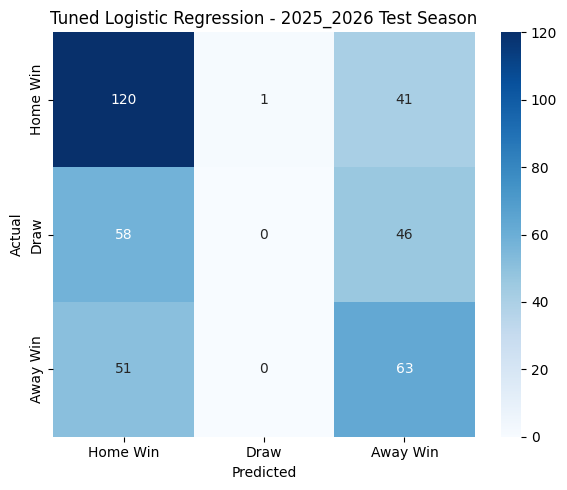

In [65]:
best_final_row = final_tuned_results.iloc[0]
best_model_name = best_final_row["model"].replace("Tuned ", "")
best_model = final_tuned_models[best_model_name]

best_pred = best_model.predict(X_test)
print("Best tuned model:", best_final_row["model"])
print("Accuracy:", round(best_final_row["accuracy"], 4))
print("Macro F1:", round(best_final_row["macro_f1"], 4))
print("Log loss:", round(best_final_row["log_loss"], 4))
print("Selected params:", best_final_row["selected_params"])

plot_confusion_matrix_from_predictions(
    y_test,
    best_pred,
    title=f"{best_final_row['model']} - 2025_2026 Test Season",
)

## 16. Notes

Bayesian tuning is done on the validation season only. The final test season is used only after hyperparameters are selected.

XGBoost is included in the model registry, but it requires the `xgboost` package. If `XGBoost available` printed `False` near the top of the notebook, install `xgboost` and rerun this notebook to include it in the tuning results.